In [ ]:
import sys, os

from matplotlib import pyplot as plt
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
import importlib
import optimizer

from scipy.stats import mannwhitneyu

In [ ]:
FIGURES_DIR = os.path.join('..', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

In [ ]:
DATA_DIR = os.path.join(os.path.dirname(__file__), '..', 'data')

df = pd.read_csv(os.path.join(DATA_DIR, 'id3_prices.csv'), index_col=0, parse_dates=True)
df = pd.DataFrame(df).iloc[1:]

df_results = pd.read_csv(os.path.join(DATA_DIR, 'predictions.csv'), index_col=0, parse_dates=True)
df_results = pd.DataFrame(df_results).iloc[1:]

df_arima_results = pd.read_csv(os.path.join(DATA_DIR, 'arima_predictions.csv'), index_col=0, parse_dates=True)
df_arima_results = pd.DataFrame(df_arima_results).iloc[1:]

df_naive = df.shift(1).dropna()

intersect_index = (df.index
                   .intersection(df_results.index)
                   .intersection(df_arima_results.index)
                   .intersection(df_naive.index))
df = df.loc[intersect_index]
df_results = df_results.loc[intersect_index]
df_arima_results = df_arima_results.loc[intersect_index]
df_naive = df_naive.loc[intersect_index]

In [ ]:
# Battery spec: 2 MWh / 1 MW / max 1.5 cycles per day
energy_cap = 2    # MWh capacity
power_cap = 1     # MW power limit
n_cycles = 1.5   # max charge-discharge cycles per day

In [ ]:
importlib.reload(optimizer)
opt = optimizer.OptimizerBESS(
    n_products=df.shape[1],
    soc_init=0,
    energy=energy_cap,
    power=power_cap,
    max_cycles=n_cycles
)

def optimize_one_day(pred_vector, actual_price_vector):
    """Run LP optimisation on predicted prices, evaluate revenue at actual prices.

    Returns
    -------
    revenue : float  – realised P&L in € for the day
    throughput : float – MWh discharged (energy cycled through the battery)
    """
    schedule = opt.optimize(pred_vector)
    revenue = float((schedule * actual_price_vector).sum())
    # throughput = MWh discharged (positive schedule = discharge, 1-h intervals)
    throughput = float(np.sum(schedule[schedule > 0]))
    return revenue, throughput

def run_strategy(pred_df, actual_df, label):
    results = Parallel(n_jobs=-1)(
        delayed(optimize_one_day)(pred_df.iloc[i].values, actual_df.iloc[i].values)
        for i in tqdm(range(len(pred_df)), desc=label)
    )
    revenues, throughputs = zip(*results)
    return np.array(revenues, dtype=float), np.array(throughputs, dtype=float)

In [ ]:
ica_rev,   ica_thru   = run_strategy(df_results,       df, "ICA-ARIMA")
arima_rev, arima_thru = run_strategy(df_arima_results, df, "ARIMA")
naive_rev, naive_thru = run_strategy(df_naive,         df, "Naive")
bench_rev, bench_thru = run_strategy(df,               df, "Perfect Foresight")

Perfect Foresight: 100%|██████████| 2820/2820 [00:01<00:00, 2653.08it/s]


In [ ]:
COLS   = ['ica', 'arima', 'naive', 'benchmark']
RENAME = {'ica': 'ICA-ARIMA', 'arima': 'ARIMA', 'naive': 'Naive', 'benchmark': 'Perfect Foresight'}

df_revenues = pd.DataFrame(
    {'ica': ica_rev, 'arima': arima_rev, 'naive': naive_rev, 'benchmark': bench_rev},
    index=df.index
)
df_throughput = pd.DataFrame(
    {'ica': ica_thru, 'arima': arima_thru, 'naive': naive_thru, 'benchmark': bench_thru},
    index=df.index
)

In [ ]:
# ── Summary Metrics ───────────────────────────────────────────────────────────
summary = {}
for col in COLS:
    rev  = df_revenues[col]
    thru = df_throughput[col]
    total_thru = thru.sum()
    summary[col] = {
        'Total Revenue (€)':     round(rev.sum(), 2),
        'Avg Daily Revenue (€)': round(rev.mean(), 2),
        '€/MWh Throughput':      round(rev.sum() / total_thru, 2) if total_thru > 0 else np.nan,
        'Capture Rate (%)':      round(rev.sum() / df_revenues['benchmark'].sum() * 100, 1),
    }

summary_df = pd.DataFrame(summary).T.rename(index=RENAME)
print("\n" + "=" * 80)
print("BESS BACKTEST — SUMMARY METRICS")
print("=" * 80)
print(summary_df.to_string())


BESS BACKTEST — SUMMARY METRICS
                   Total Revenue (€)  Avg Daily Revenue (€)  €/MWh Throughput  Capture Rate (%)
ICA-ARIMA                  458255.77                 162.50             54.18              81.6
ARIMA                      433956.66                 153.89             51.30              77.3
Naive                      406242.32                 144.06             48.07              72.4
Perfect Foresight          561270.85                 199.03             66.41             100.0


In [ ]:
# ── Statistical Tests ─────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("MANN-WHITNEY U TESTS  (H1: ICA-ARIMA daily revenue > baseline)")
print("=" * 80)
for baseline, label in [('arima', 'ARIMA'), ('naive', 'Naive'), ('benchmark', 'Perfect Foresight')]:
    stat = mannwhitneyu(df_revenues['ica'], df_revenues[baseline], alternative='greater')
    rel  = (df_revenues['ica'].sum() - df_revenues[baseline].sum()) / abs(df_revenues[baseline].sum())
    print(f"  ICA vs {label:20s}: p={stat.pvalue:.4f}   rel_diff={rel:+.2%}")


MANN-WHITNEY U TESTS  (H1: ICA-ARIMA daily revenue > baseline)
  ICA vs ARIMA               : p=0.0032   rel_diff=+5.60%
  ICA vs Naive               : p=0.0000   rel_diff=+12.80%
  ICA vs Perfect Foresight   : p=1.0000   rel_diff=-18.35%


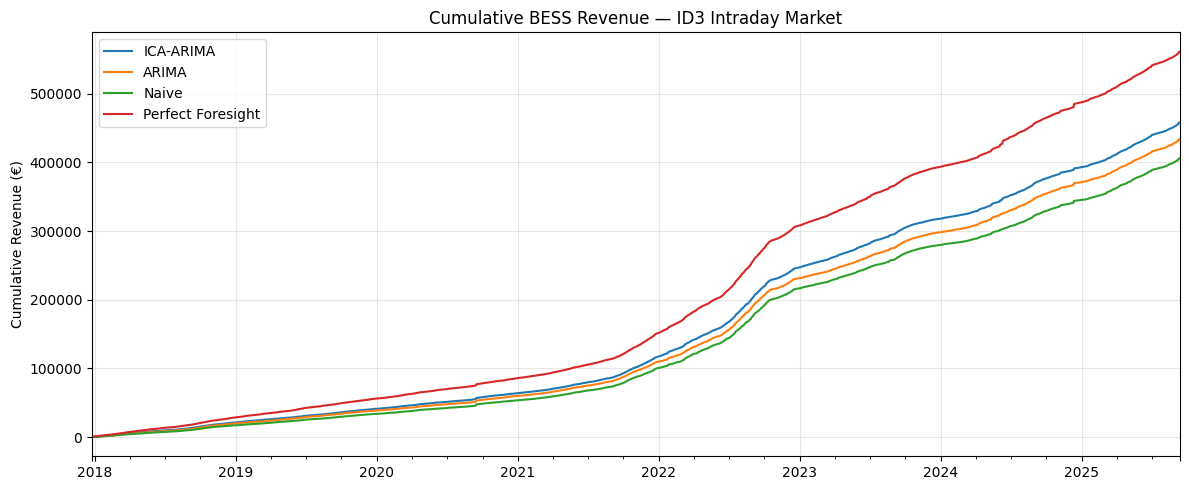

In [ ]:
# ── Cumulative Revenue ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
df_revenues[COLS].rename(columns=RENAME).cumsum().plot(ax=ax)
ax.set_title("Cumulative BESS Revenue — ID3 Intraday Market")
ax.set_ylabel("Cumulative Revenue (€)")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
plt.tight_layout()

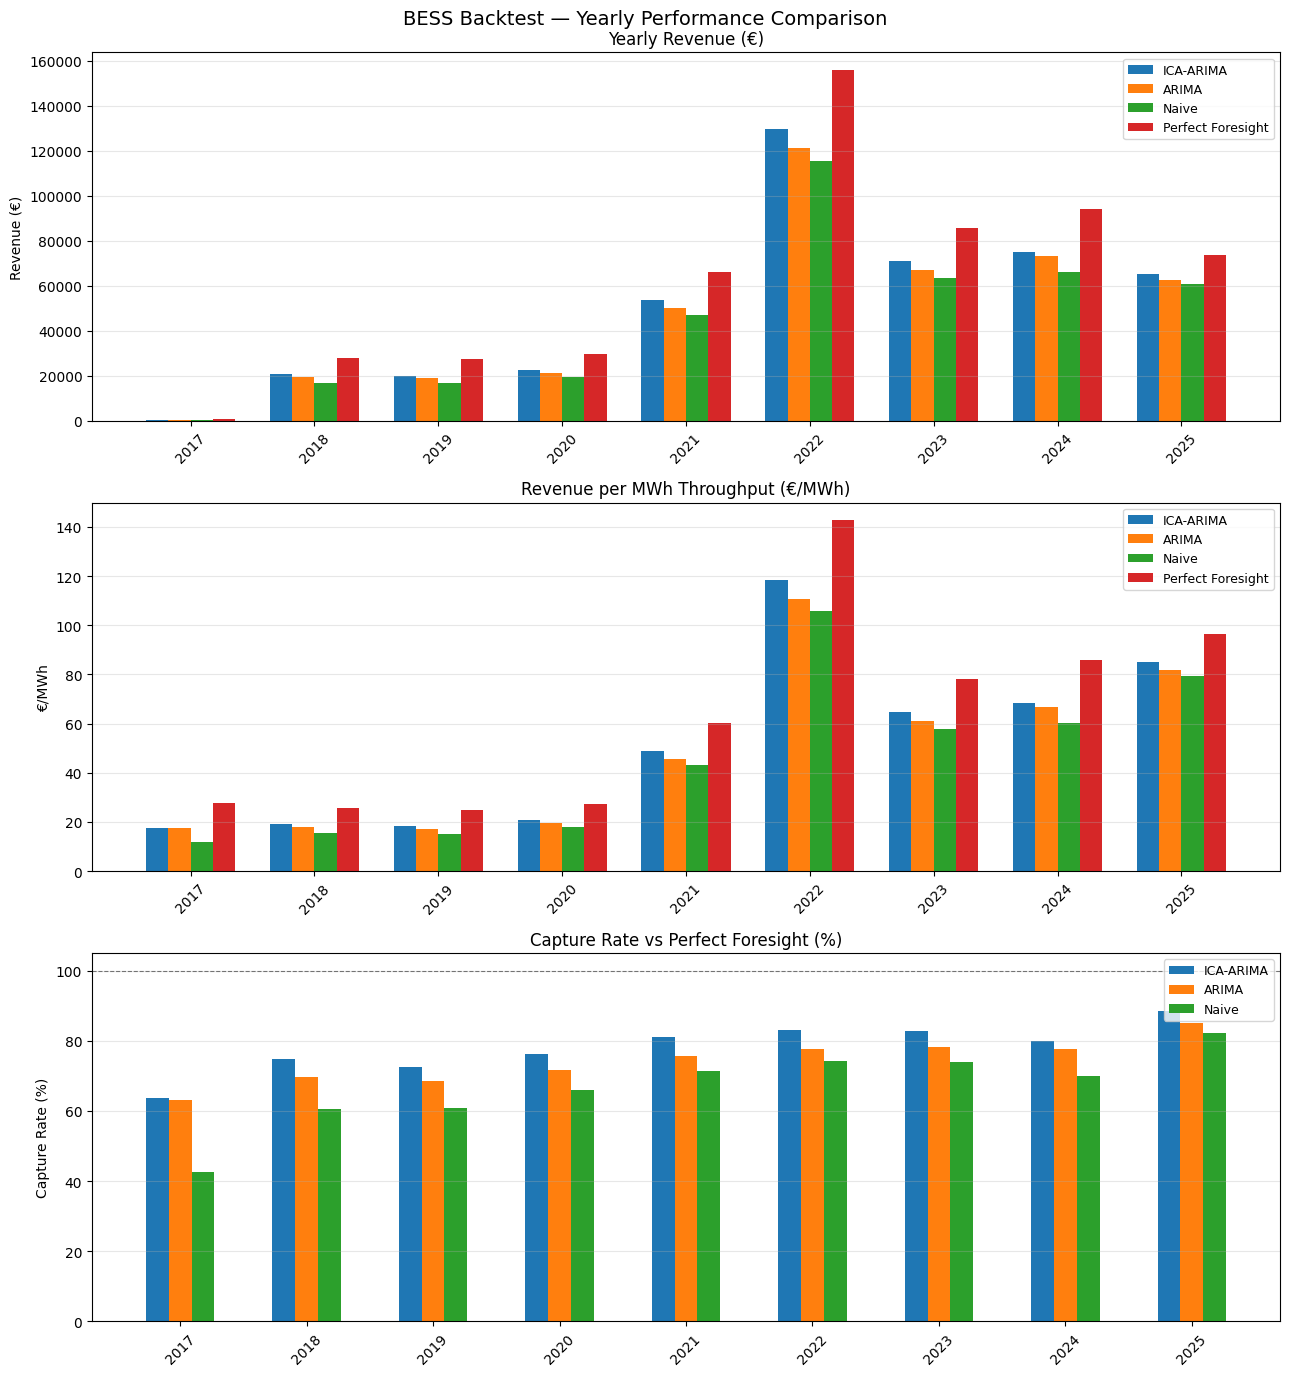

In [ ]:
# ── Yearly Multi-Panel Comparison ─────────────────────────────────────────────
yearly_rev  = df_revenues[COLS].resample("YE").sum()
yearly_thru = df_throughput[COLS].resample("YE").sum()
yearly_eur  = (yearly_rev / yearly_thru).rename(columns=RENAME)
yearly_cap  = (yearly_rev.div(yearly_rev['benchmark'], axis=0) * 100
               ).drop(columns='benchmark').rename(columns=RENAME)
yearly_rev  = yearly_rev.rename(columns=RENAME)

year_labels = yearly_rev.index.year.astype(str).tolist()
x     = np.arange(len(year_labels))
bar_w = 0.18

fig, axes = plt.subplots(3, 1, figsize=(13, 14))
panels = [
    (yearly_rev, "Yearly Revenue (€)",                    "Revenue (€)"),
    (yearly_eur, "Revenue per MWh Throughput (€/MWh)",    "€/MWh"),
    (yearly_cap, "Capture Rate vs Perfect Foresight (%)", "Capture Rate (%)"),
]
for ax, (data, title, ylabel) in zip(axes, panels):
    cols    = data.columns.tolist()
    offsets = (np.arange(len(cols)) - (len(cols) - 1) / 2) * bar_w
    for col, offset in zip(cols, offsets):
        ax.bar(x + offset, data[col], width=bar_w, label=col)
    ax.set_xticks(x)
    ax.set_xticklabels(year_labels, rotation=45)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
axes[2].axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='Perfect Foresight')
plt.suptitle("BESS Backtest — Yearly Performance Comparison", fontsize=14)
plt.tight_layout()

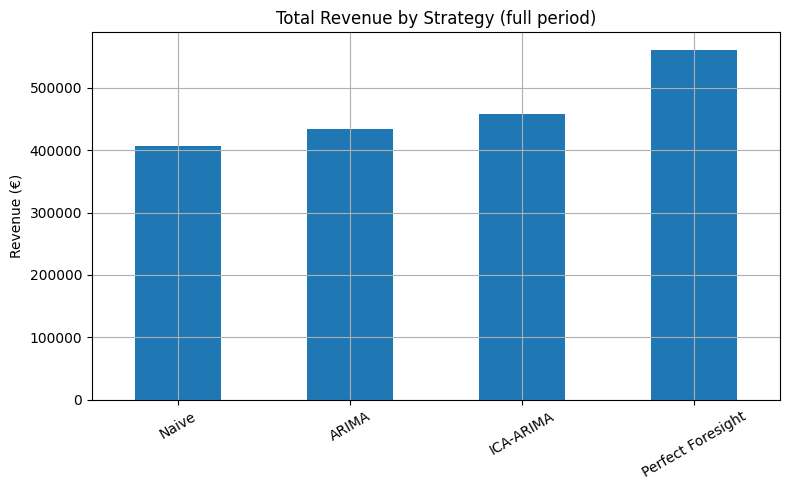

In [ ]:
# ── Total Revenue Bar ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df_revenues[COLS].sum().rename(index=RENAME).sort_values().plot.bar(ax=ax, grid=True)
ax.set_title("Total Revenue by Strategy (full period)")
ax.set_ylabel("Revenue (€)")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()

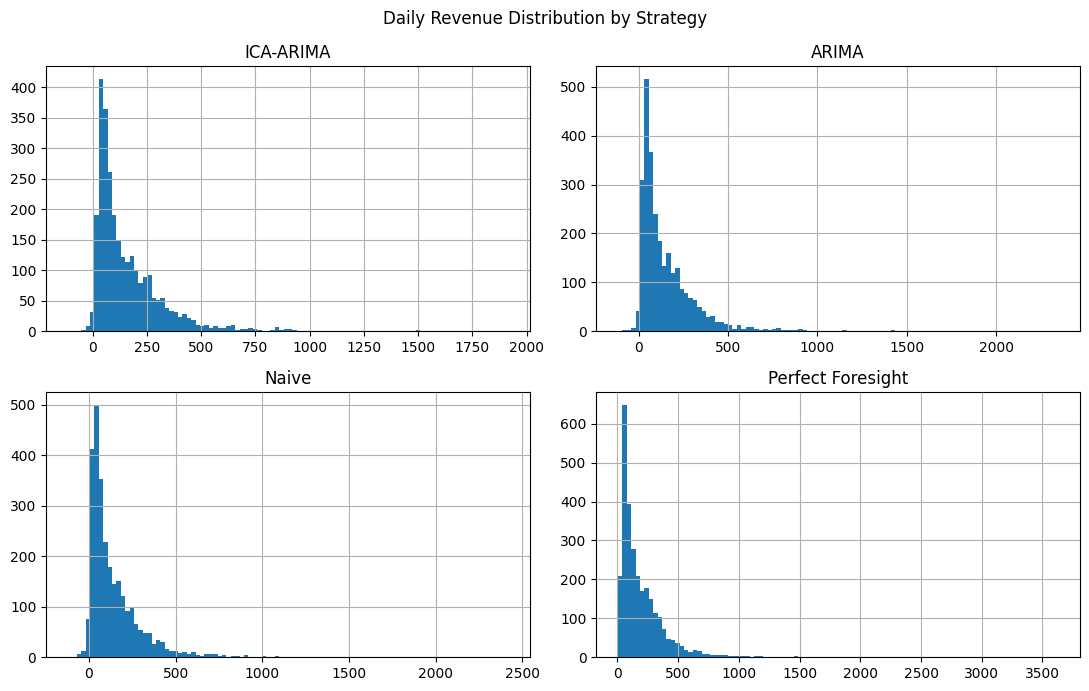

In [ ]:
# ── Daily Revenue Distribution ────────────────────────────────────────────────
df_revenues[COLS].rename(columns=RENAME).hist(bins=100, figsize=(11, 7))
plt.suptitle("Daily Revenue Distribution by Strategy")
plt.tight_layout()